In [ ]:
# =========================================
# REGRESIÓN LINEAL - ÓXIDO NITROSO
# Autor: Juan José Velasco
# Notebook: Intervalos hipotesis
# =========================================

In [ ]:
# Intervalos de Confianza y Predicción

#En este notebook se estiman los niveles de emisión de óxido nitroso utilizando el modelo de regresión lineal seleccionado previamente.

#Se construirán intervalos de confianza para la media esperada de emisiones e intervalos de predicción para observaciones individuales bajo diferentes condiciones ambientales.

In [1]:
#Importacion de librerías
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.formula.api as smf

In [2]:
# Cargar el dataset
df = pd.read_excel("../data/oxido nitroso.xls")


# Renombrar columnas con nombres limpios para la regresión
df.columns = [
    "NOx",        # Óxido nitroso
    "Humidity",     # Humedad relativa
    "Temp",        # Temperatura
    "Pressure"   # Presión atmosférica
]

df.head()

,NOx,Humidity,Temp,Pressure
0,0.90,72.4,76.3,29.18
1,0.91,41.6,70.3,29.35
2,0.96,34.3,77.1,29.24
3,0.89,35.1,68.0,29.27
4,1.00,10.7,79.0,29.78


In [3]:
#Nuevos datos para predicción
nuevos = pd.DataFrame({
    "Humidity": [48.16, 38.16]
})

nuevos

,Humidity
0,48.16
1,38.16


In [ ]:
# Estimación de intervalos de confianza y predicción para el modelo basado en Humidity
modelo_h = smf.ols("NOx ~ Humidity", data=df).fit()
predicciones = modelo_h.get_prediction(nuevos)

intervalos = predicciones.summary_frame(alpha=0.05)

intervalos

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,0.954366,0.012899,0.927266,0.981466,0.831823,1.076909
1,0.987601,0.012898,0.960502,1.014700,0.865058,1.110144


In [ ]:
# Combinar los nuevos datos con los intervalos de confianza y predicción
resultado = pd.concat([nuevos, intervalos], axis=1)

resultado

,Humidity,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,48.16,0.954366,0.012899,0.927266,0.981466,0.831823,1.076909
1,38.16,0.987601,0.012898,0.960502,1.014700,0.865058,1.110144


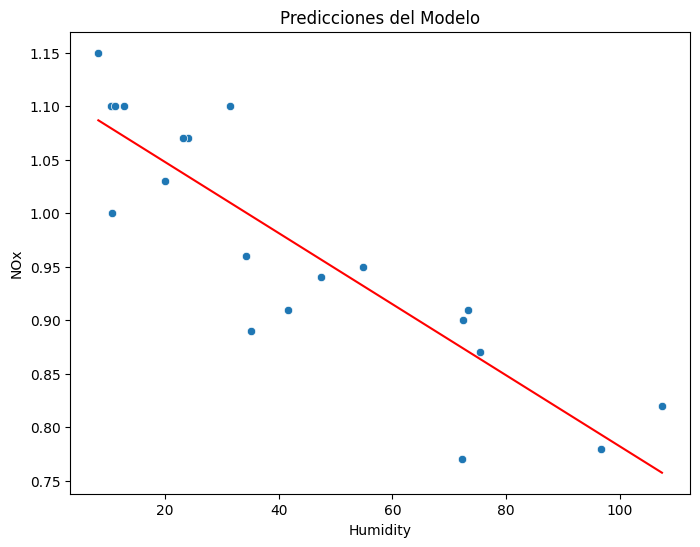

: 

In [ ]:
# Visualización de las predicciones del modelo junto con los datos observados
plt.figure(figsize=(8,6))

sns.scatterplot(data=df, x="Humidity", y="NOx")

sns.lineplot(
    x=df["Humidity"],
    y=modelo_h.fittedvalues,
    color="red"
)

plt.title("Predicciones del Modelo")

plt.show()

In [ ]:
# Interpretación

# Para una humedad relativa de 48.16%, el modelo estima un nivel promedio de emisiones de NOx 
# de aproximadamente 0.95 ppm.
# El intervalo de confianza (95%) para la media esperada está entre 0.93 y 0.98 ppm.
# El intervalo de predicción para una observación individual futura está entre 0.83 y 1.08 ppm.

# Para una humedad relativa de 38.16%, el modelo estima un nivel promedio de emisiones de NOx 
# de aproximadamente 0.99 ppm.
# El intervalo de confianza (95%) para la media esperada está entre 0.96 y 1.01 ppm.
# El intervalo de predicción para una observación individual futura está entre 0.87 y 1.11 ppm.
